In [1]:
import sys
sys.path.append("/opt/lakehouse/lakehouse")

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, sum as spark_sum, when
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from lakehouse.paths import PathResolver

# =========================
# SPARK SESSION & DATA LOADING
# =========================
spark = (
    SparkSession.builder
    .appName("Dashboard_Plots")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

resolver = PathResolver()

s3_gold_path_kpi = resolver.s3_layer_path(
    layer="gold",
    dataset="kpi_dashboard"
)

s3_silver_path_client_contrat = resolver.s3_layer_path(
    layer="silver",
    dataset="Client_contrat_silver"
)

# Read data
df_kpi = spark.read.parquet(s3_gold_path_kpi)
df_silver = spark.read.parquet(s3_silver_path_client_contrat)

# Convert to Pandas
kpi_df = df_kpi.toPandas()
silver_df = df_silver.toPandas()

print(" Data loaded successfully")
print(f"   - KPI records: {len(kpi_df)}")
print(f"   - Silver records: {len(silver_df)}")



26/02/10 13:10:23 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
26/02/10 13:10:23 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
26/02/10 13:10:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Data loaded successfully
   - KPI records: 5
   - Silver records: 170613


In [2]:
#  DEBUG: Print KPI columns
print("\n DEBUG - KPI DataFrame columns:")
print(kpi_df.columns.tolist())
print("\nKPI DataFrame head:")
print(kpi_df.head())

#  DEBUG: Print Silver columns
print("\n DEBUG - Silver DataFrame columns:")
print(silver_df.columns.tolist())

# =========================
# CALCULATE KPIs DIRECTLY FROM SILVER IF GOLD TABLE MISSING COLUMNS
# =========================
if 'kpi_name' not in kpi_df.columns:
    print("\n  WARNING: 'kpi_name' column not found in KPI table")
    print("   Calculating KPIs directly from Silver data...")
    
    # Calculate KPIs from silver data
    MONTH_REPORT = pd.Timestamp.now().month
    YEAR_REPORT = pd.Timestamp.now().year
    
    total_records = len(silver_df)
    
    # KPI 1: Market Share
    active_contracts = (silver_df['contrat_actif'] == 1).sum()
    market_share_pct = round((active_contracts / total_records * 100), 2)
    
    # KPI 2: Retention Rate
    resigned_contracts = len(silver_df[
        (silver_df['etat_contrat_libelle'].str.contains('Résilié', na=False)) | 
        (silver_df['etat_contrat_libelle'] == 'Annulé')
    ])
    retention_rate = round(((total_records - resigned_contracts) / total_records * 100), 2)
    
    # KPI 3: Young Ratio
    young_total = (silver_df['client_jeune'] == 1).sum()
    young_ratio_pct = round((young_total / total_records * 100), 2)
    
    # KPI 4: Average Premium
    avg_premium_all = round(silver_df['prmaco'].mean(), 2)
    
    # KPI 5: High-Risk
    high_risk_young_moto = (silver_df['jeune_moto'] == 1).sum()
    high_risk_pct = round((high_risk_young_moto / total_records * 100), 2)
    
    # Create KPI DataFrame
    kpi_data = [
        {
            "kpi_id": 1,
            "kpi_name": "Market Share (Active Contracts)",
            "kpi_value": active_contracts,
            "kpi_total": total_records,
            "kpi_percentage": market_share_pct,
            "kpi_target": 50,
            "kpi_status": "ON TRACK" if market_share_pct >= 50 else "AT RISK",
            "report_month": MONTH_REPORT,
            "report_year": YEAR_REPORT
        },
        {
            "kpi_id": 2,
            "kpi_name": "Retention Rate",
            "kpi_value": total_records - resigned_contracts,
            "kpi_total": total_records,
            "kpi_percentage": retention_rate,
            "kpi_target": 97,
            "kpi_status": "ON TRACK" if retention_rate >= 97 else "AT RISK",
            "report_month": MONTH_REPORT,
            "report_year": YEAR_REPORT
        },
        {
            "kpi_id": 3,
            "kpi_name": "Young Customer Ratio (<30)",
            "kpi_value": young_total,
            "kpi_total": total_records,
            "kpi_percentage": young_ratio_pct,
            "kpi_target": 35,
            "kpi_status": "ON TRACK" if young_ratio_pct >= 35 else "AT RISK",
            "report_month": MONTH_REPORT,
            "report_year": YEAR_REPORT
        },
        {
            "kpi_id": 4,
            "kpi_name": "Average Premium (EUR)",
            "kpi_value": avg_premium_all,
            "kpi_total": total_records,
            "kpi_percentage": 0.0,
            "kpi_target": 0,
            "kpi_status": "INFORMATIVE",
            "report_month": MONTH_REPORT,
            "report_year": YEAR_REPORT
        },
        {
            "kpi_id": 5,
            "kpi_name": "High-Risk Young Drivers (Moto)",
            "kpi_value": high_risk_young_moto,
            "kpi_total": total_records,
            "kpi_percentage": high_risk_pct,
            "kpi_target": 10,
            "kpi_status": "CRITICAL" if high_risk_pct > 20 else "WARNING" if high_risk_pct > 10 else "OK",
            "report_month": MONTH_REPORT,
            "report_year": YEAR_REPORT
        }
    ]
    
    kpi_df = pd.DataFrame(kpi_data)
    print(" KPIs calculated from Silver data")

print("\n Final KPI DataFrame:")
print(kpi_df)



 DEBUG - KPI DataFrame columns:
['_1', '_2', '_3', '_4', '_5', '_6', '_7', '_8', '_9']

KPI DataFrame head:
   _1                               _2        _3      _4     _5    _6  \
0   1  Market Share (Active Contracts)  19859.00  170613  11.64  50.0   
1   3       Young Customer Ratio (<30)     66.00  170613   0.04  35.0   
2   5   High-Risk Young Drivers (Moto)     49.00  170613   0.03  10.0   
3   4            Average Premium (EUR)    418.88  170613   0.00   0.0   
4   2                   Retention Rate  26019.00  170613  15.25  97.0   

            _7  _8    _9  
0      AT RISK   1  2026  
1      AT RISK   1  2026  
2           OK   1  2026  
3  INFORMATIVE   1  2026  
4      AT RISK   1  2026  

 DEBUG - Silver DataFrame columns:
['nusoc', 'nucon', 'cateco', 'g01co', 'g02co', 'g03co', 'g04co', 'g05co', 'g06co', 'g09co', 'g10co', 'g13co', 'g15co', 'g16co', 'g17co', 'g18co', 'g19co', 'g21co', 'g22co', 'g23co', 'g25co', 'g26co', 'g28co', 'clasco', 'tar6co', 'bomaco', 'fracco', 'famg


 Generating Dashboard 1: 5 KPI Indicators


/tmp/ipykernel_30813/632144086.py:64: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_30813/632144086.py:65: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.savefig('/tmp/dashboard_1_kpi_indicators.png', dpi=300, bbox_inches='tight')


 Saved: /tmp/dashboard_1_kpi_indicators.png


/usr/local/lib/python3.8/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


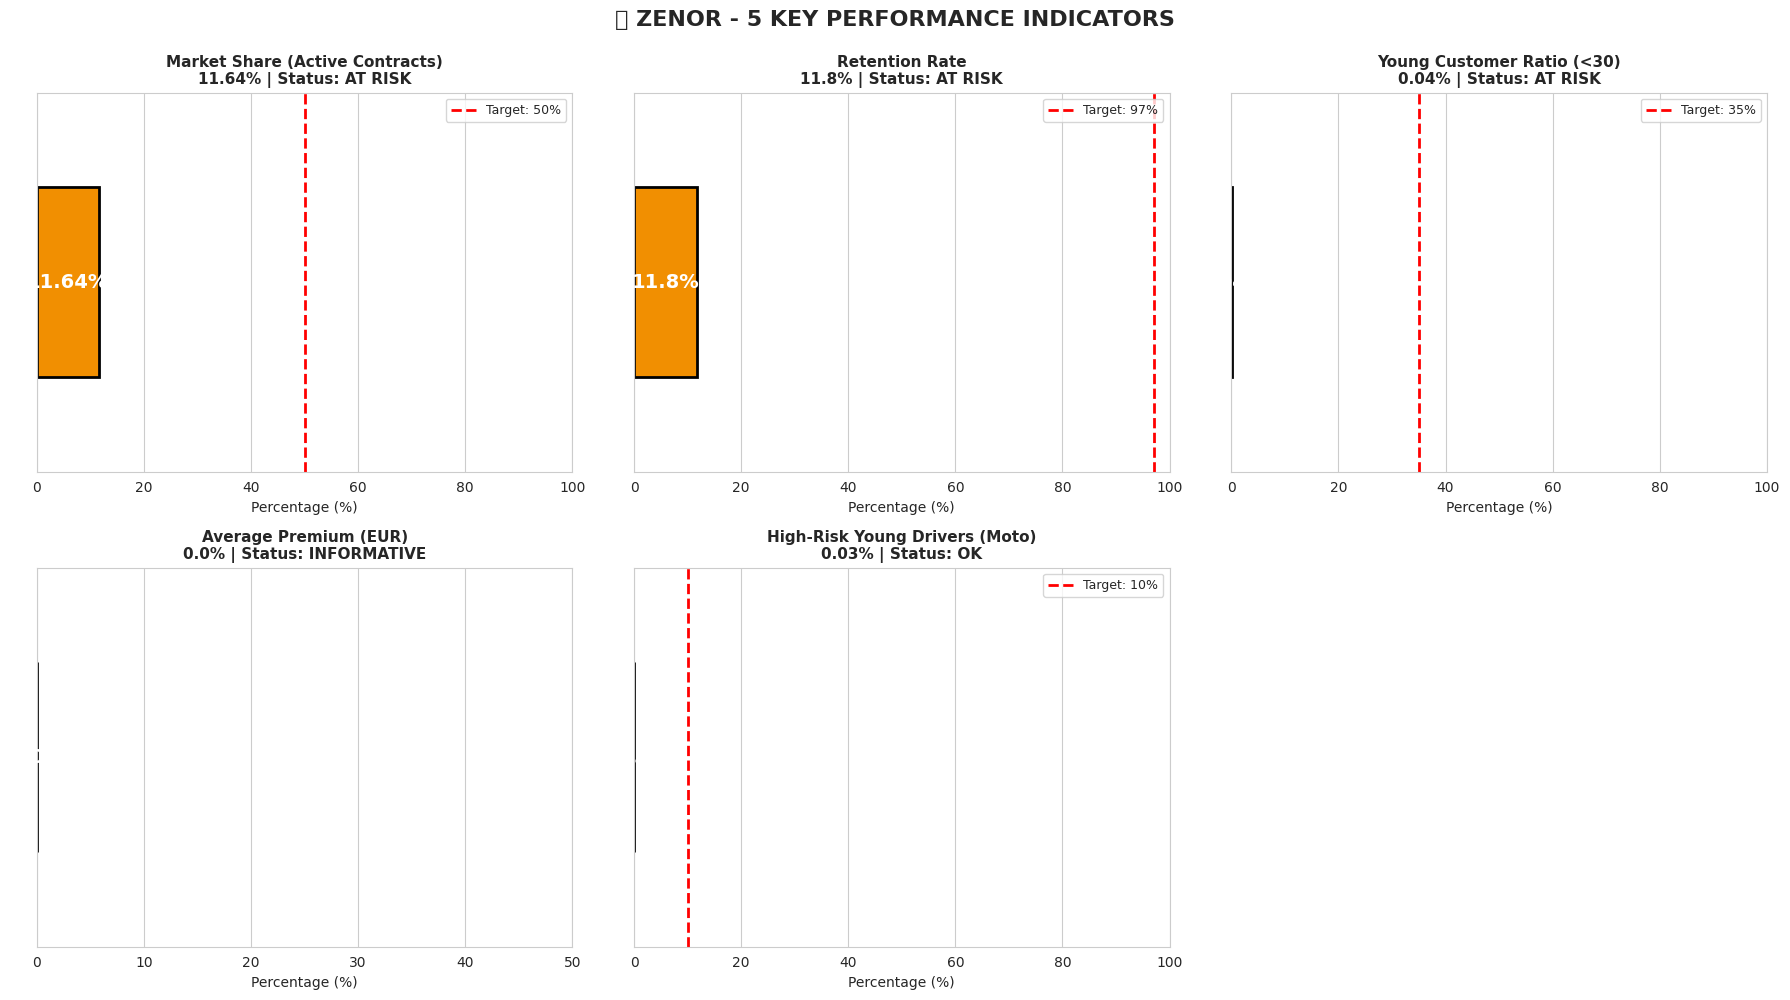

In [3]:
# =========================
# SETUP STYLE
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

# Colors
colors_palette = ["#2E86AB", "#A23B72", "#F18F01", "#06A77D", "#C73E1D"]
sns.set_palette(colors_palette)

# =========================
# DASHBOARD 1: 5 KPI INDICATORS
# =========================
print("\n Generating Dashboard 1: 5 KPI Indicators")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(' ZENOR - 5 KEY PERFORMANCE INDICATORS', fontsize=16, fontweight='bold', y=0.995)

# Flatten axes
axes = axes.flatten()

for idx, row in kpi_df.iterrows():
    ax = axes[idx]
    
    kpi_name = row['kpi_name']
    kpi_value = row['kpi_percentage']
    kpi_target = row['kpi_target']
    kpi_status = row['kpi_status']
    
    # Determine color
    if 'ON TRACK' in kpi_status:
        bar_color = '#06A77D'
    elif 'AT RISK' in kpi_status:
        bar_color = '#F18F01'
    else:
        bar_color = '#2E86AB'
    
    # Create horizontal bar
    ax.barh([0], [kpi_value], color=bar_color, height=0.5, edgecolor='black', linewidth=2)
    
    # Add target line
    if kpi_target > 0:
        ax.axvline(kpi_target, color='red', linestyle='--', linewidth=2, label=f'Target: {kpi_target}%')
    
    # Styling
    ax.set_xlim(0, 100 if kpi_target > 0 else max(kpi_value * 1.2, 50))
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_title(f'{kpi_name}\n{kpi_value}% | Status: {kpi_status}', 
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Percentage (%)')
    
    # Add value label
    ax.text(kpi_value/2, 0, f'{kpi_value}%', 
           ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    
    if kpi_target > 0:
        ax.legend(loc='upper right', fontsize=9)

# Remove last subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig('/tmp/dashboard_1_kpi_indicators.png', dpi=300, bbox_inches='tight')
print(" Saved: /tmp/dashboard_1_kpi_indicators.png")
plt.show()


 Generating Dashboard 2: Contract Distribution
 Saved: /tmp/dashboard_2_vehicle_distribution.png


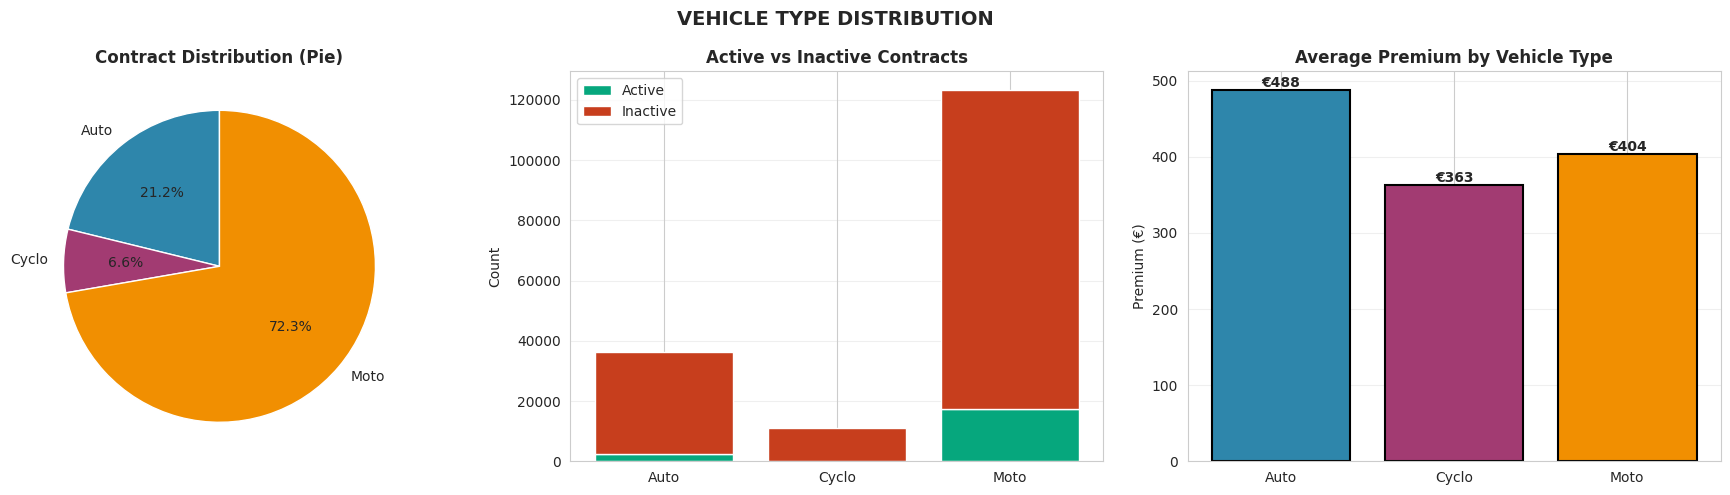

In [4]:
# =========================
# DASHBOARD 2: CONTRACT BY VEHICLE TYPE
# =========================
print("\n Generating Dashboard 2: Contract Distribution")

vehicle_stats = silver_df.groupby('type_vehicule').agg({
    'nucon': 'count',
    'contrat_actif': 'sum',
    'prmaco': 'mean'
}).reset_index()
vehicle_stats.columns = ['Vehicle Type', 'Total Contracts', 'Active', 'Avg Premium']
vehicle_stats['Inactive'] = vehicle_stats['Total Contracts'] - vehicle_stats['Active']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VEHICLE TYPE DISTRIBUTION', fontsize=14, fontweight='bold')

# Pie chart
ax1 = axes[0]
ax1.pie(vehicle_stats['Total Contracts'], labels=vehicle_stats['Vehicle Type'], 
        autopct='%1.1f%%', colors=colors_palette, startangle=90)
ax1.set_title('Contract Distribution (Pie)', fontweight='bold')

# Stacked bar: Active vs Inactive
ax2 = axes[1]
x_pos = np.arange(len(vehicle_stats))
ax2.bar(x_pos, vehicle_stats['Active'], label='Active', color='#06A77D')
ax2.bar(x_pos, vehicle_stats['Inactive'], bottom=vehicle_stats['Active'], 
        label='Inactive', color='#C73E1D')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(vehicle_stats['Vehicle Type'])
ax2.set_ylabel('Count')
ax2.set_title('Active vs Inactive Contracts', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Average Premium by type
ax3 = axes[2]
bars = ax3.bar(vehicle_stats['Vehicle Type'], vehicle_stats['Avg Premium'], 
              color=colors_palette[:len(vehicle_stats)], edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Premium (€)')
ax3.set_title('Average Premium by Vehicle Type', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'€{height:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/dashboard_2_vehicle_distribution.png', dpi=300, bbox_inches='tight')
print(" Saved: /tmp/dashboard_2_vehicle_distribution.png")
plt.show()



 Generating Dashboard 3: Age Segment Analysis
 Saved: /tmp/dashboard_3_age_analysis.png


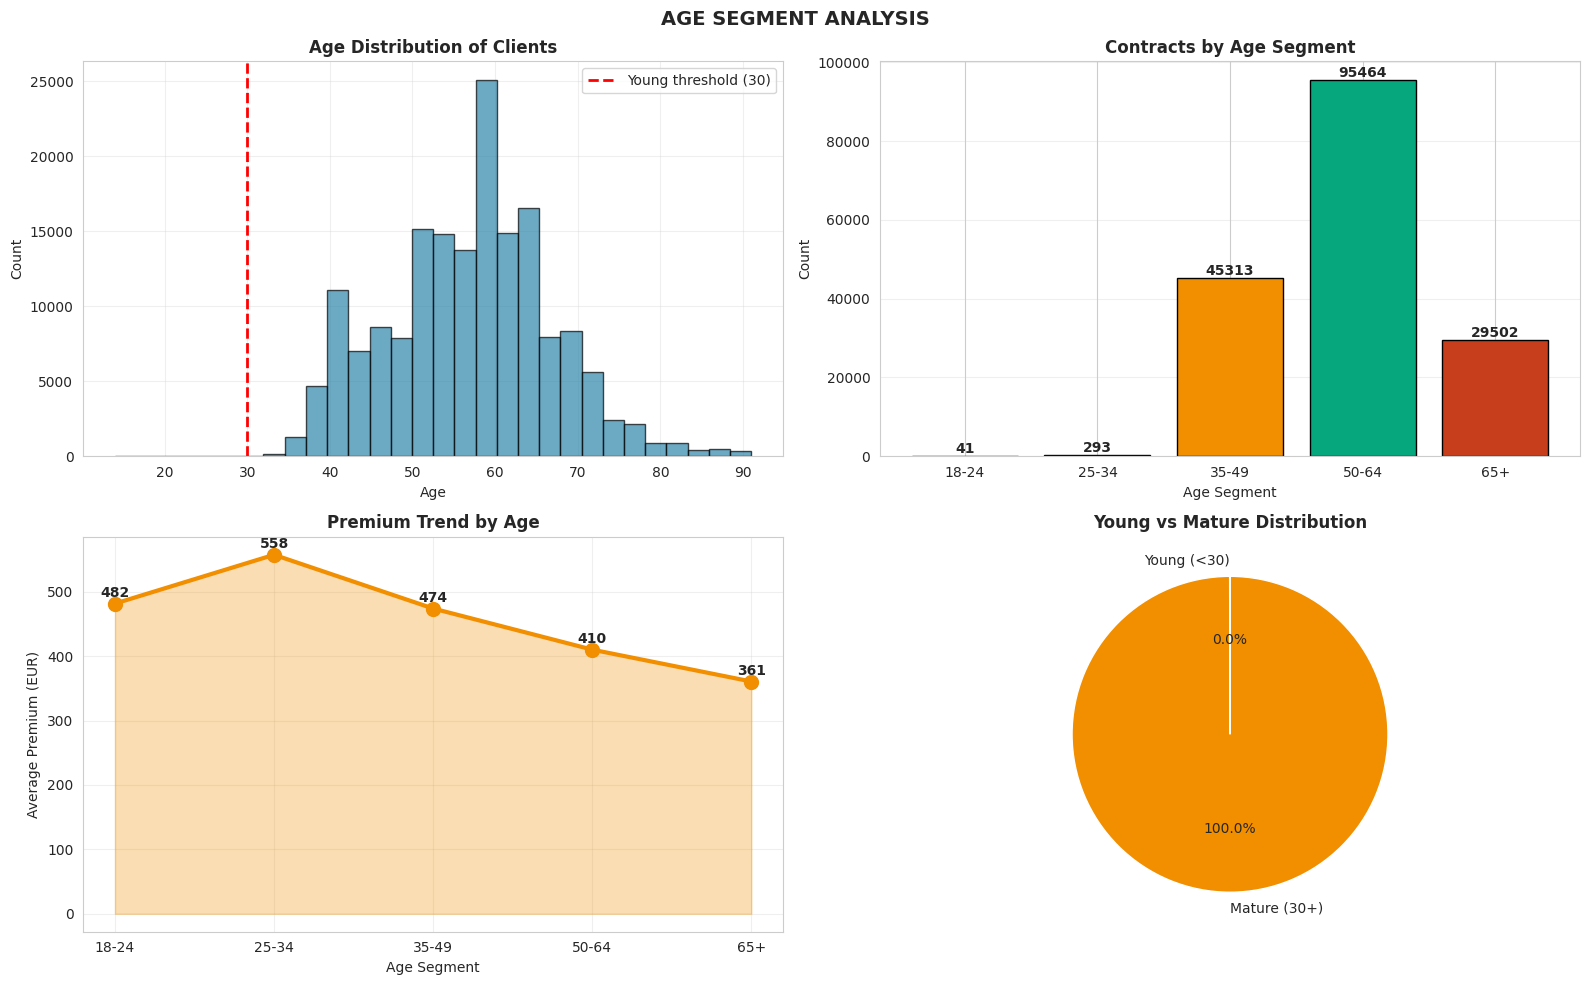

In [5]:
# =========================
# DASHBOARD 3: AGE ANALYSIS
# =========================
print("\n Generating Dashboard 3: Age Segment Analysis")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('AGE SEGMENT ANALYSIS', fontsize=14, fontweight='bold')

# Create age segments
silver_df['age_segment'] = pd.cut(silver_df['age_client'], 
    bins=[0, 25, 35, 50, 65, 150], 
    labels=['18-24', '25-34', '35-49', '50-64', '65+'])

# 1. Histogram: Age distribution
ax1 = axes[0, 0]
ax1.hist(silver_df['age_client'], bins=30, color='#2E86AB', edgecolor='black', alpha=0.7)
ax1.axvline(30, color='red', linestyle='--', linewidth=2, label='Young threshold (30)')
ax1.set_xlabel('Age')
ax1.set_ylabel('Count')
ax1.set_title('Age Distribution of Clients', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Bar: Contracts by age segment
ax2 = axes[0, 1]
age_segment_stats = silver_df['age_segment'].value_counts().sort_index()
bars = ax2.bar(age_segment_stats.index, age_segment_stats.values, color=colors_palette, edgecolor='black')
ax2.set_xlabel('Age Segment')
ax2.set_ylabel('Count')
ax2.set_title('Contracts by Age Segment', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 3. Avg Premium by age segment
ax3 = axes[1, 0]
age_premium = silver_df.groupby('age_segment')['prmaco'].mean()
ax3.plot(age_premium.index, age_premium.values, marker='o', linewidth=3, 
        markersize=10, color='#F18F01')
ax3.fill_between(range(len(age_premium)), age_premium.values, alpha=0.3, color='#F18F01')
ax3.set_xlabel('Age Segment')
ax3.set_ylabel('Average Premium (EUR)')
ax3.set_title('Premium Trend by Age', fontweight='bold')
ax3.grid(alpha=0.3)

# Add value labels
for i, (idx, val) in enumerate(age_premium.items()):
    ax3.text(i, val + 10, f'{val:.0f}', ha='center', fontweight='bold')

# 4. Young vs Mature pie
ax4 = axes[1, 1]
young_count = (silver_df['client_jeune'] == 1).sum()
mature_count = (silver_df['client_jeune'] == 0).sum()
ax4.pie([young_count, mature_count], labels=['Young (<30)', 'Mature (30+)'],
       autopct='%1.1f%%', colors=['#2E86AB', '#F18F01'], startangle=90)
ax4.set_title('Young vs Mature Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/dashboard_3_age_analysis.png', dpi=300, bbox_inches='tight')
print(" Saved: /tmp/dashboard_3_age_analysis.png")
plt.show()


 Generating Dashboard 4: Risk Profiling


/tmp/ipykernel_30813/701796454.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=risk_df, x='Risk Group', y='Premium', ax=ax2, palette=['#C73E1D', '#F18F01', '#06A77D'])


 Saved: /tmp/dashboard_4_risk_profiling.png


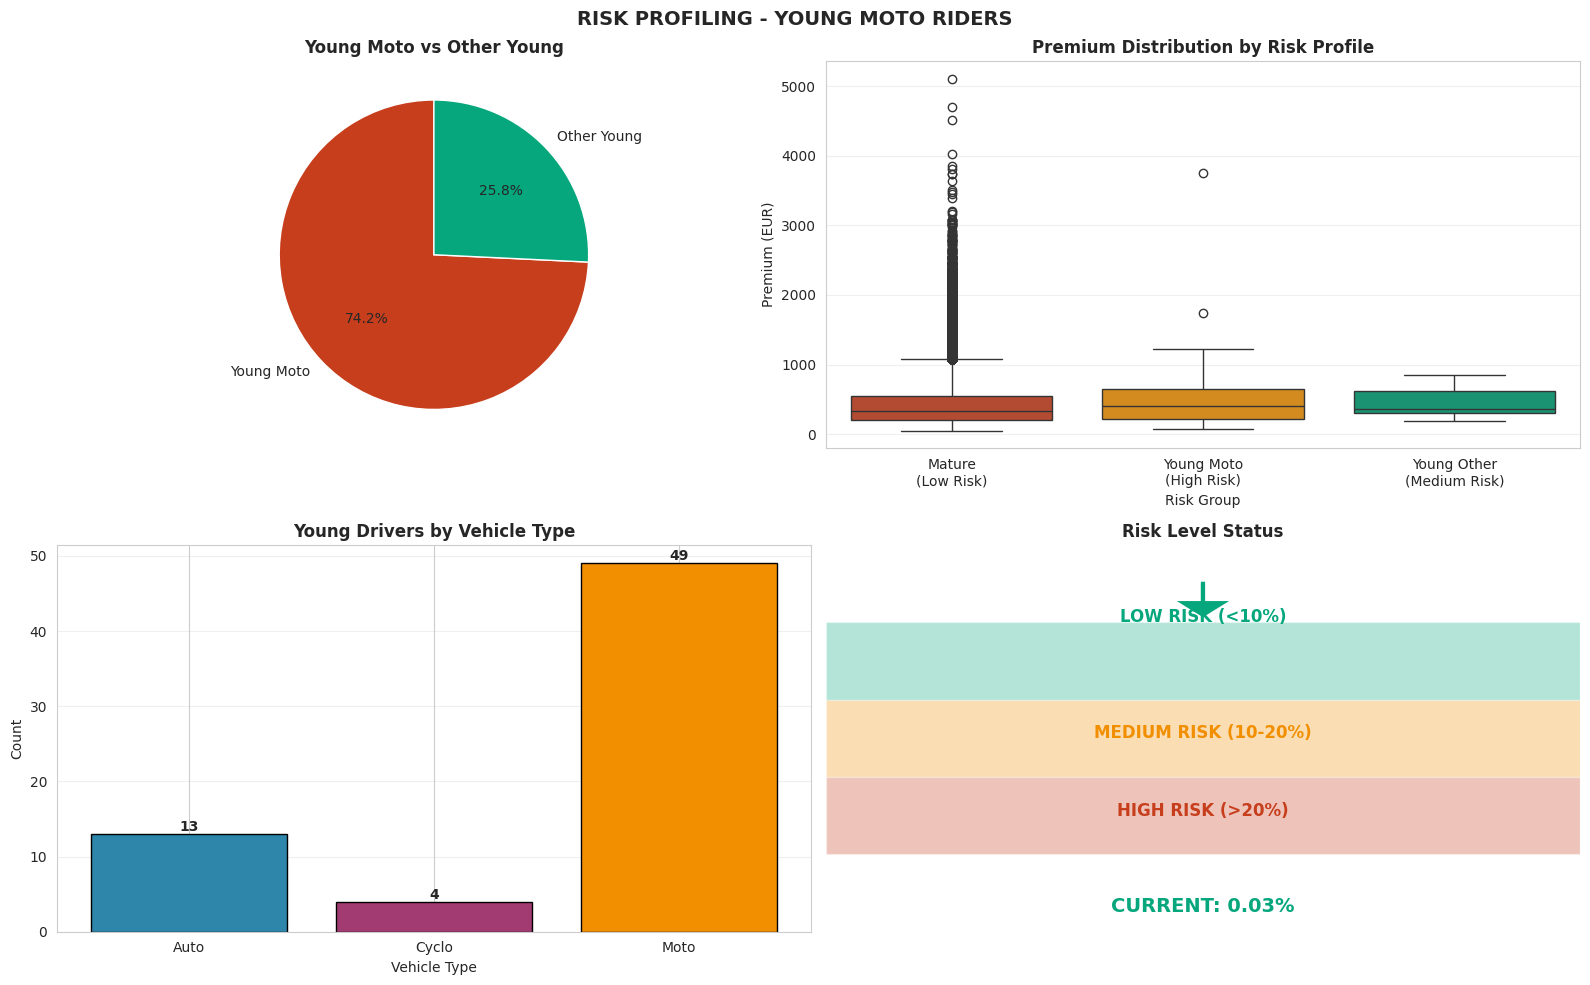

In [6]:
# =========================
# DASHBOARD 4: RISK PROFILING
# =========================
print("\n Generating Dashboard 4: Risk Profiling")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('RISK PROFILING - YOUNG MOTO RIDERS', fontsize=14, fontweight='bold')

# 1. Young Moto pie
ax1 = axes[0, 0]
young_moto_count = (silver_df['jeune_moto'] == 1).sum()
other_young = (silver_df['client_jeune'] == 1).sum() - young_moto_count
ax1.pie([young_moto_count, other_young], labels=['Young Moto', 'Other Young'],
       autopct='%1.1f%%', colors=['#C73E1D', '#06A77D'], startangle=90)
ax1.set_title('Young Moto vs Other Young', fontweight='bold')

# 2. Premium distribution by risk
ax2 = axes[0, 1]
risk_groups = []
premium_vals = []
for idx, row in silver_df.iterrows():
    if row['jeune_moto'] == 1:
        risk_groups.append('Young Moto\n(High Risk)')
    elif row['client_jeune'] == 1:
        risk_groups.append('Young Other\n(Medium Risk)')
    else:
        risk_groups.append('Mature\n(Low Risk)')
    premium_vals.append(row['prmaco'])

risk_df = pd.DataFrame({'Risk Group': risk_groups, 'Premium': premium_vals})
sns.boxplot(data=risk_df, x='Risk Group', y='Premium', ax=ax2, palette=['#C73E1D', '#F18F01', '#06A77D'])
ax2.set_ylabel('Premium (EUR)')
ax2.set_title('Premium Distribution by Risk Profile', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Young drivers by vehicle type
ax3 = axes[1, 0]
young_by_vehicle = silver_df[silver_df['client_jeune'] == 1].groupby('type_vehicule').size()
bars = ax3.bar(young_by_vehicle.index, young_by_vehicle.values, color=colors_palette[:len(young_by_vehicle)], edgecolor='black')
ax3.set_xlabel('Vehicle Type')
ax3.set_ylabel('Count')
ax3.set_title('Young Drivers by Vehicle Type', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 4. Risk status gauge
ax4 = axes[1, 1]
risk_pct = (young_moto_count / len(silver_df)) * 100
ax4.axis('off')

from matplotlib.patches import Rectangle
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 10)

# Risk level zones
ax4.add_patch(Rectangle((0, 6), 10, 2, facecolor='#06A77D', alpha=0.3))
ax4.add_patch(Rectangle((0, 4), 10, 2, facecolor='#F18F01', alpha=0.3))
ax4.add_patch(Rectangle((0, 2), 10, 2, facecolor='#C73E1D', alpha=0.3))

ax4.text(5, 8, 'LOW RISK (<10%)', ha='center', fontsize=12, fontweight='bold', color='#06A77D')
ax4.text(5, 5, 'MEDIUM RISK (10-20%)', ha='center', fontsize=12, fontweight='bold', color='#F18F01')
ax4.text(5, 3, 'HIGH RISK (>20%)', ha='center', fontsize=12, fontweight='bold', color='#C73E1D')

current_level = 9 - (risk_pct / 30 * 5)
color = '#06A77D' if risk_pct < 10 else '#F18F01' if risk_pct < 20 else '#C73E1D'
ax4.arrow(5, current_level, 0, -0.5, head_width=0.5, head_length=0.3, fc=color, ec=color, linewidth=3)
ax4.text(5, 0.5, f'CURRENT: {risk_pct:.2f}%', ha='center', fontsize=14, fontweight='bold', color=color)

ax4.set_title('Risk Level Status', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('/tmp/dashboard_4_risk_profiling.png', dpi=300, bbox_inches='tight')
print(" Saved: /tmp/dashboard_4_risk_profiling.png")
plt.show()



 Generating Dashboard 5: Contract Status Analysis
 Saved: /tmp/dashboard_5_contract_status.png


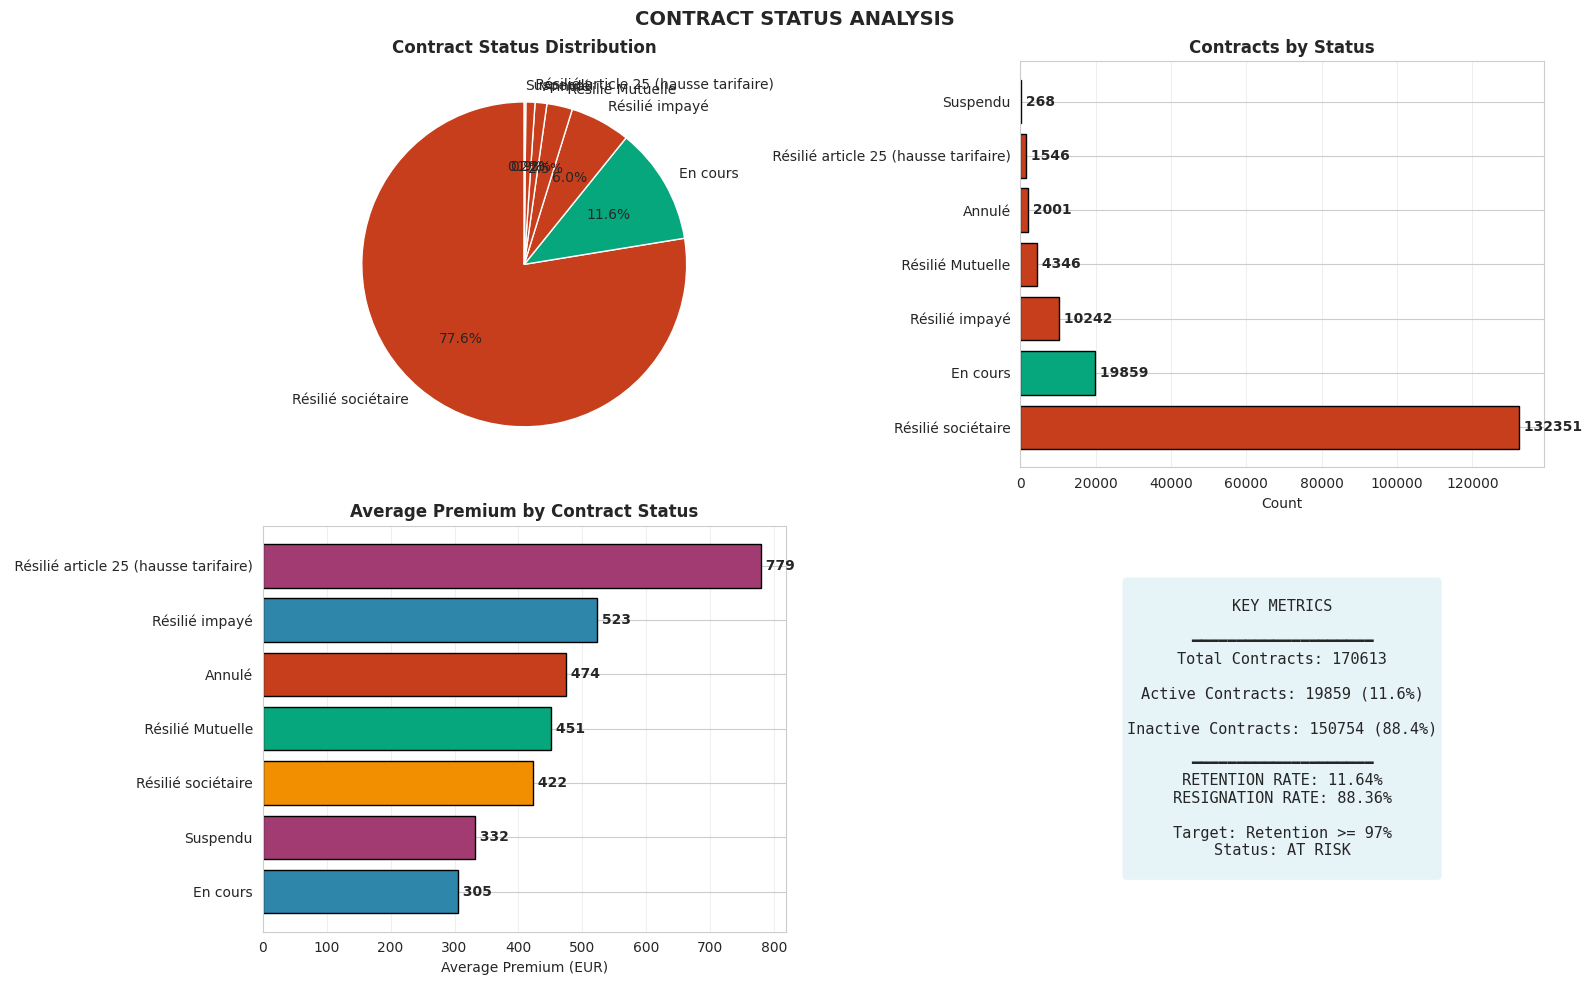

In [7]:
# =========================
# DASHBOARD 5: CONTRACT STATUS ANALYSIS
# =========================
print("\n Generating Dashboard 5: Contract Status Analysis")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('CONTRACT STATUS ANALYSIS', fontsize=14, fontweight='bold')

# Status distribution
status_counts = silver_df['etat_contrat_libelle'].value_counts()

# 1. Pie: Contract status
ax1 = axes[0, 0]
colors_status = ['#06A77D' if 'En cours' in str(s) else '#C73E1D' for s in status_counts.index]
ax1.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
       colors=colors_status, startangle=90)
ax1.set_title('Contract Status Distribution', fontweight='bold')

# 2. Bar: Status count
ax2 = axes[0, 1]
bars = ax2.barh(status_counts.index, status_counts.values, color=colors_status, edgecolor='black')
ax2.set_xlabel('Count')
ax2.set_title('Contracts by Status', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)}', ha='left', va='center', fontweight='bold')

# 3. Average premium by status
ax3 = axes[1, 0]
premium_by_status = silver_df.groupby('etat_contrat_libelle')['prmaco'].mean().sort_values()
bars = ax3.barh(premium_by_status.index, premium_by_status.values, color=colors_palette, edgecolor='black')
ax3.set_xlabel('Average Premium (EUR)')
ax3.set_title('Average Premium by Contract Status', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
            f' {width:.0f}', ha='left', va='center', fontweight='bold')

# 4. Retention metrics
ax4 = axes[1, 1]
ax4.axis('off')

total_contracts = len(silver_df)
active_contracts = (silver_df['contrat_actif'] == 1).sum()
resigned = total_contracts - active_contracts
retention_rate = (active_contracts / total_contracts) * 100
resignation_rate = (resigned / total_contracts) * 100

metrics_text = f"""
KEY METRICS

━━━━━━━━━━━━━━━━━━━━
Total Contracts: {total_contracts}

Active Contracts: {active_contracts} ({(active_contracts/total_contracts)*100:.1f}%)

Inactive Contracts: {resigned} ({resignation_rate:.1f}%)

━━━━━━━━━━━━━━━━━━━━
RETENTION RATE: {retention_rate:.2f}%
RESIGNATION RATE: {resignation_rate:.2f}%

Target: Retention >= 97%
Status: {'ON TRACK' if retention_rate >= 97 else 'AT RISK'}
"""

ax4.text(0.5, 0.5, metrics_text, transform=ax4.transAxes,
        fontsize=11, verticalalignment='center', horizontalalignment='center',
        fontfamily='monospace', 
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig('/tmp/dashboard_5_contract_status.png', dpi=300, bbox_inches='tight')
print(" Saved: /tmp/dashboard_5_contract_status.png")
plt.show()

In [8]:
# =========================
# SUMMARY REPORT
# =========================
print("\n" + "="*80)
print("DASHBOARDS GENERATED SUCCESSFULLY")
print("="*80)

print("\n Saved visualizations:")
print("  1   /tmp/dashboard_1_kpi_indicators.png")
print("  2  /tmp/dashboard_2_vehicle_distribution.png")
print("  3  /tmp/dashboard_3_age_analysis.png")
print("  4  /tmp/dashboard_4_risk_profiling.png")
print("  5  /tmp/dashboard_5_contract_status.png")

print("\n   KEY INSIGHTS:")
print(f"  • Total Contracts: {len(silver_df)}")
print(f"  • Young Customers (<30): {(silver_df['client_jeune']==1).sum()}")
print(f"  • Young Moto Riders: {(silver_df['jeune_moto']==1).sum()}")
print(f"  • Avg Premium: {silver_df['prmaco'].mean():.2f}")
print(f"  • Retention Rate: {retention_rate:.2f}%")

spark.stop()


DASHBOARDS GENERATED SUCCESSFULLY

 Saved visualizations:
  1   /tmp/dashboard_1_kpi_indicators.png
  2  /tmp/dashboard_2_vehicle_distribution.png
  3  /tmp/dashboard_3_age_analysis.png
  4  /tmp/dashboard_4_risk_profiling.png
  5  /tmp/dashboard_5_contract_status.png

  KEY INSIGHTS:
  • Total Contracts: 170613
  • Young Customers (<30): 66
  • Young Moto Riders: 49
  • Avg Premium: 418.88
  • Retention Rate: 11.64%
